# Run infection dynamics with monoclonal killer T cell response

In [1]:
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy import stats
import os
from stoch_sim_model import *
from optimize_nets import *
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
%load_ext line_profiler

In [2]:
# %lprun -T lprof0 -f agent_stoch_sim agent_stoch_sim(N_0 = 100, infection ='prim')

### (1) Plot sample trajectory

In [41]:
# Set simulation parameters
N_0 = 100
K_IE = 10**4
#d_I = 2*d_S
infection_type = "prim" #"prim", "sec"
sim_type = "agent" #"pop_ode", "agent"
reg = 1*np.array([-0.5, -0.5, 0.0, 0.0, 0.0, -1.0, 0.5, -0.5, 0.0]) 
#np.array([1.0, 1.0, 0.0, -1.0, -1.0, 0.0, 1.0, 1.0, 0.0])

In [42]:
# Run single simulation
# %timeit -n 2 -r 2
data_dict = agent_stoch_sim(N_0 = N_0, b_I = b_I, 
                            K_IE = 10*K_IE,
                          d_I = 10*d_S,
                          K_IH = K_IH,
                          regulation_coeffs =  reg,
                          infection = infection_type,
                          vir_model = "dep_harm")

In [43]:
regs = data_dict["reg_coeffs"]
dyn = data_dict["cell_time_series"]
ts = data_dict["time"]
lin_comp = data_dict["lineage_diff"]
p_diff = data_dict["prim_diff_bias"]
sim_summary = data_dict["sumary_stats"]
Eff = data_dict["eff_by_lin"]
mycNa = data_dict["Na_myc_by_lin"]
myccM = data_dict["cMa_myc_by_lin"]
mycEin = data_dict["Ein_myc_by_lin"]
mycEout = data_dict["Eout_myc_by_lin"]

S, I, A, Na, E, cM, eM, H, I_d_I, I_d_S = dyn[:,-10], dyn[:,-9], dyn[:,-8], dyn[:,-7], dyn[:,-6], dyn[:,-5], dyn[:,-4], dyn[:,-3], dyn[:,-2], dyn[:,-1]

reg_string = '-'.join((reg * 1).astype('U1'))

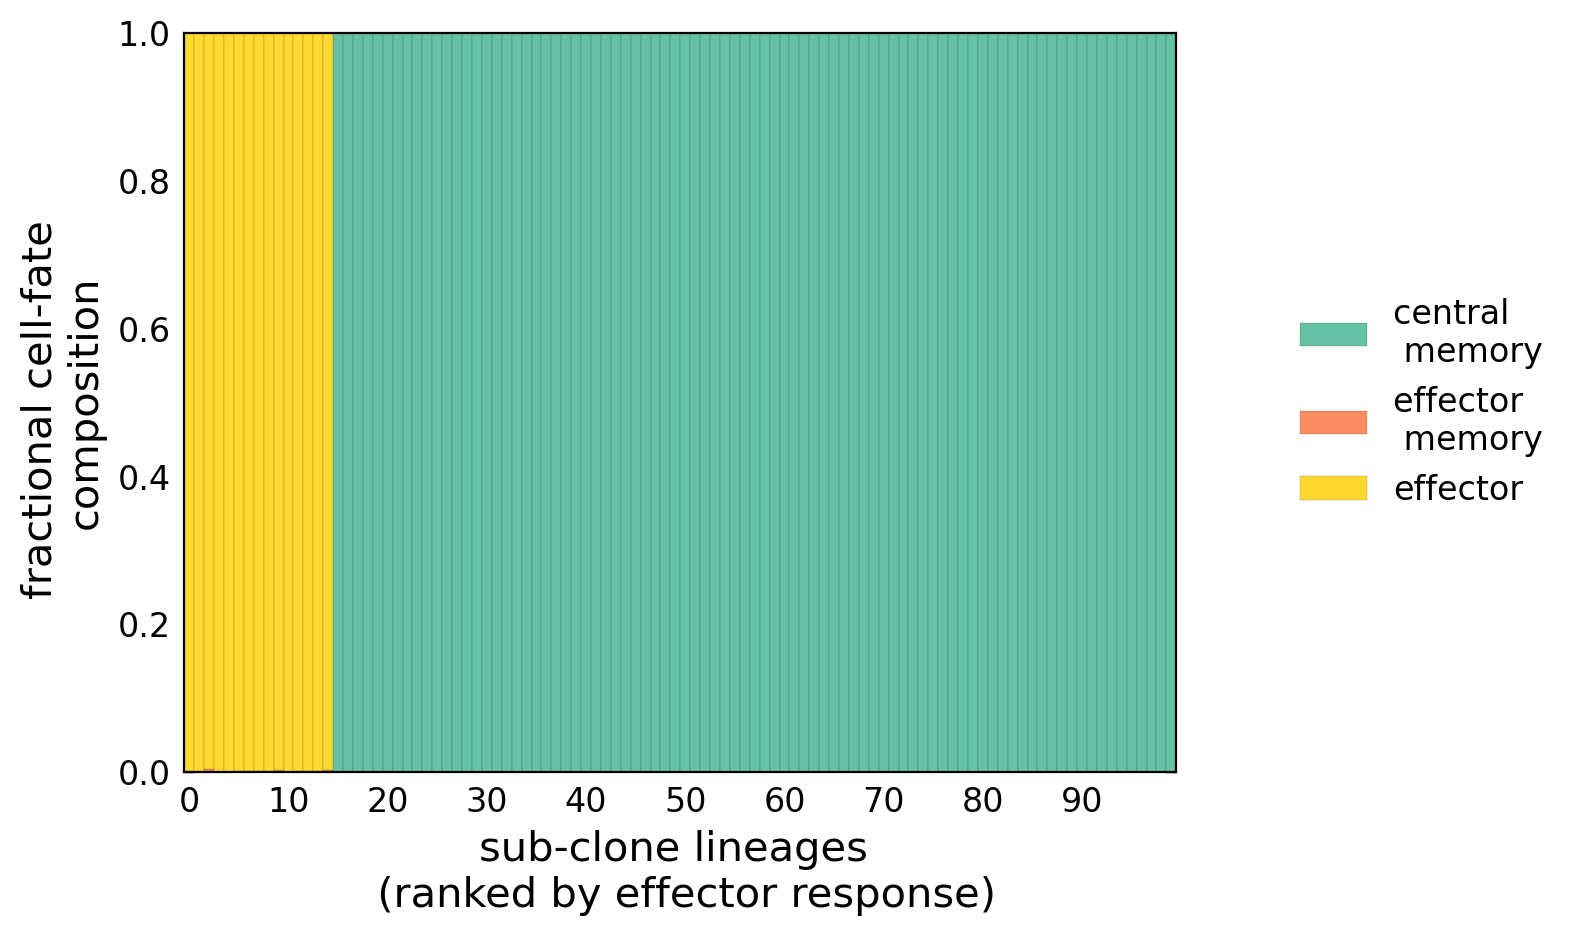

In [44]:
keys = np.array(['central \n memory', 'effector', 'effector \n memory'])
all_counts = lin_comp[0:-2].T
effector_ranking = np.argsort(all_counts[:, 1])[::-1]
all_counts = all_counts[effector_ranking]
total_counts = all_counts.sum(axis=1)
norm_counts = all_counts / total_counts[:, None]
norm_counts[~np.isfinite(norm_counts)] = 0
comp_argsort = np.argsort(np.max(all_counts, axis=0))
bar_dict = {k: v for k, v in zip(keys[comp_argsort], norm_counts.T[comp_argsort])}
lineage_idxs = np.arange(all_counts.shape[0])

fig, ax = plt.subplots()
bottom = np.zeros(len(lineage_idxs))
cmap_colors = sns.color_palette('Set2', 10)
cmap_colors = [cmap_colors[i]
               for i in [0, 1, 5]]#[7, 2, 0, 1, 5]]
# cmap_colors = [cmap_colors[i]
#                for i in [6, 1, 2, 5, 0]]
width = 1

for i, (celltype, fraction) in enumerate(bar_dict.items()):
    ax.bar(lineage_idxs, fraction, width,
           edgecolor='k', linewidth=0.05,
           label=celltype, bottom=bottom, color=cmap_colors[i])
    bottom += fraction
    
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5), fontsize = 12)
ax.set_xlim(-0.5, len(all_counts) - 0.5)
ax.set_xlabel('sub-clone lineages \n (ranked by effector response)', fontsize = 15)
ax.set_ylabel('fractional cell-fate \ncomposition', fontsize = 15)
#ax.set_yscale('log')

ax.set_xticks(np.arange(0, N_0, 10))
ax.set_xticklabels(ax.get_xticks(), fontsize=12)

ax.set_yticks(np.round(np.arange(0, 1.2, 0.2), 1))
ax.set_yticklabels(ax.get_yticks(), fontsize=12)

fig.savefig("_figs/"+infection_type+'-'+'fates-by-lin-'+reg_string+'.png', dpi=300, bbox_inches="tight")


[]

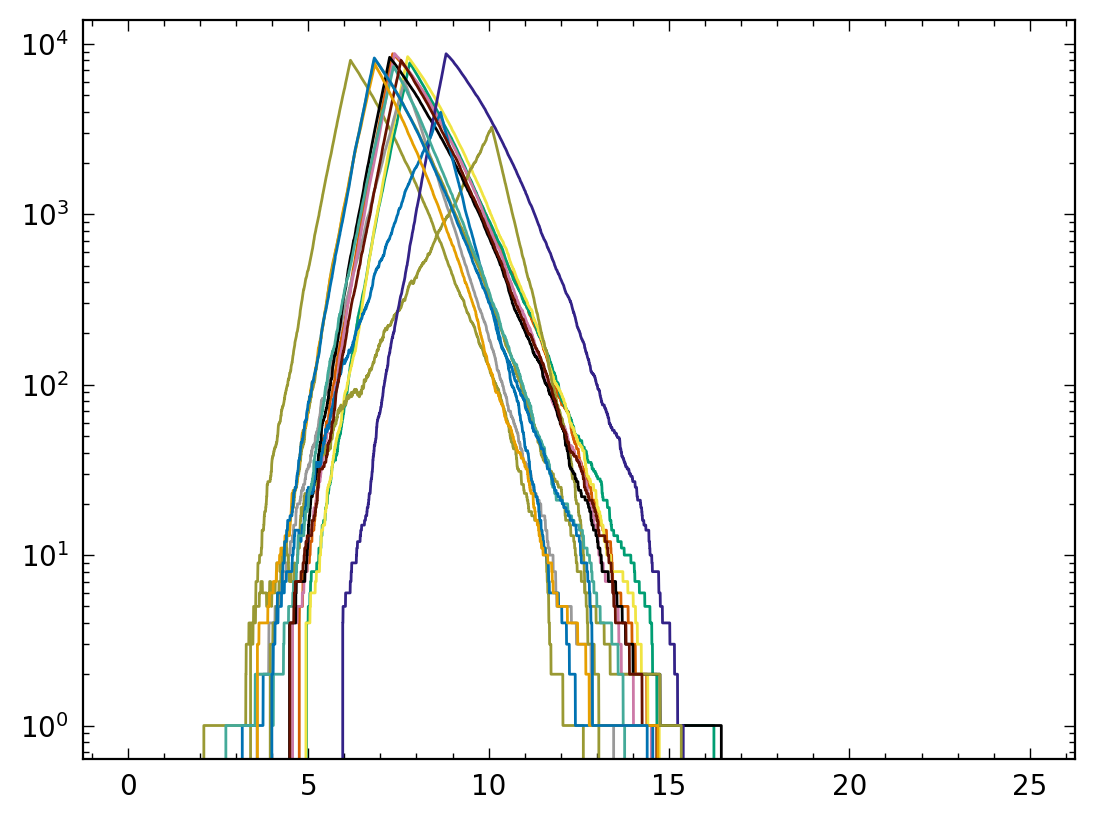

In [45]:
plt.plot(ts, Eff)
plt.semilogy()

[]

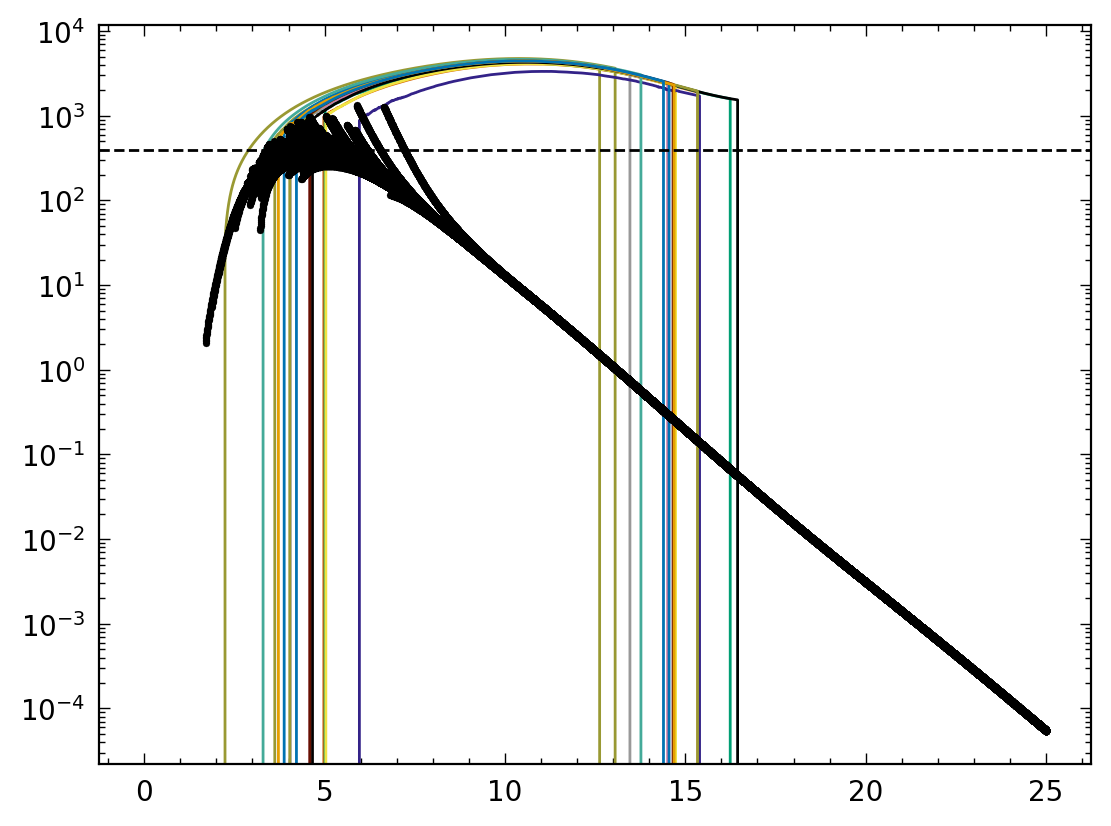

In [46]:
plt.plot(ts, mycEout) #, 'r--')
plt.plot(ts, myccM, 'k.')
plt.axhline(y = myc_thresh, color = 'k', linestyle = '--')
plt.semilogy()

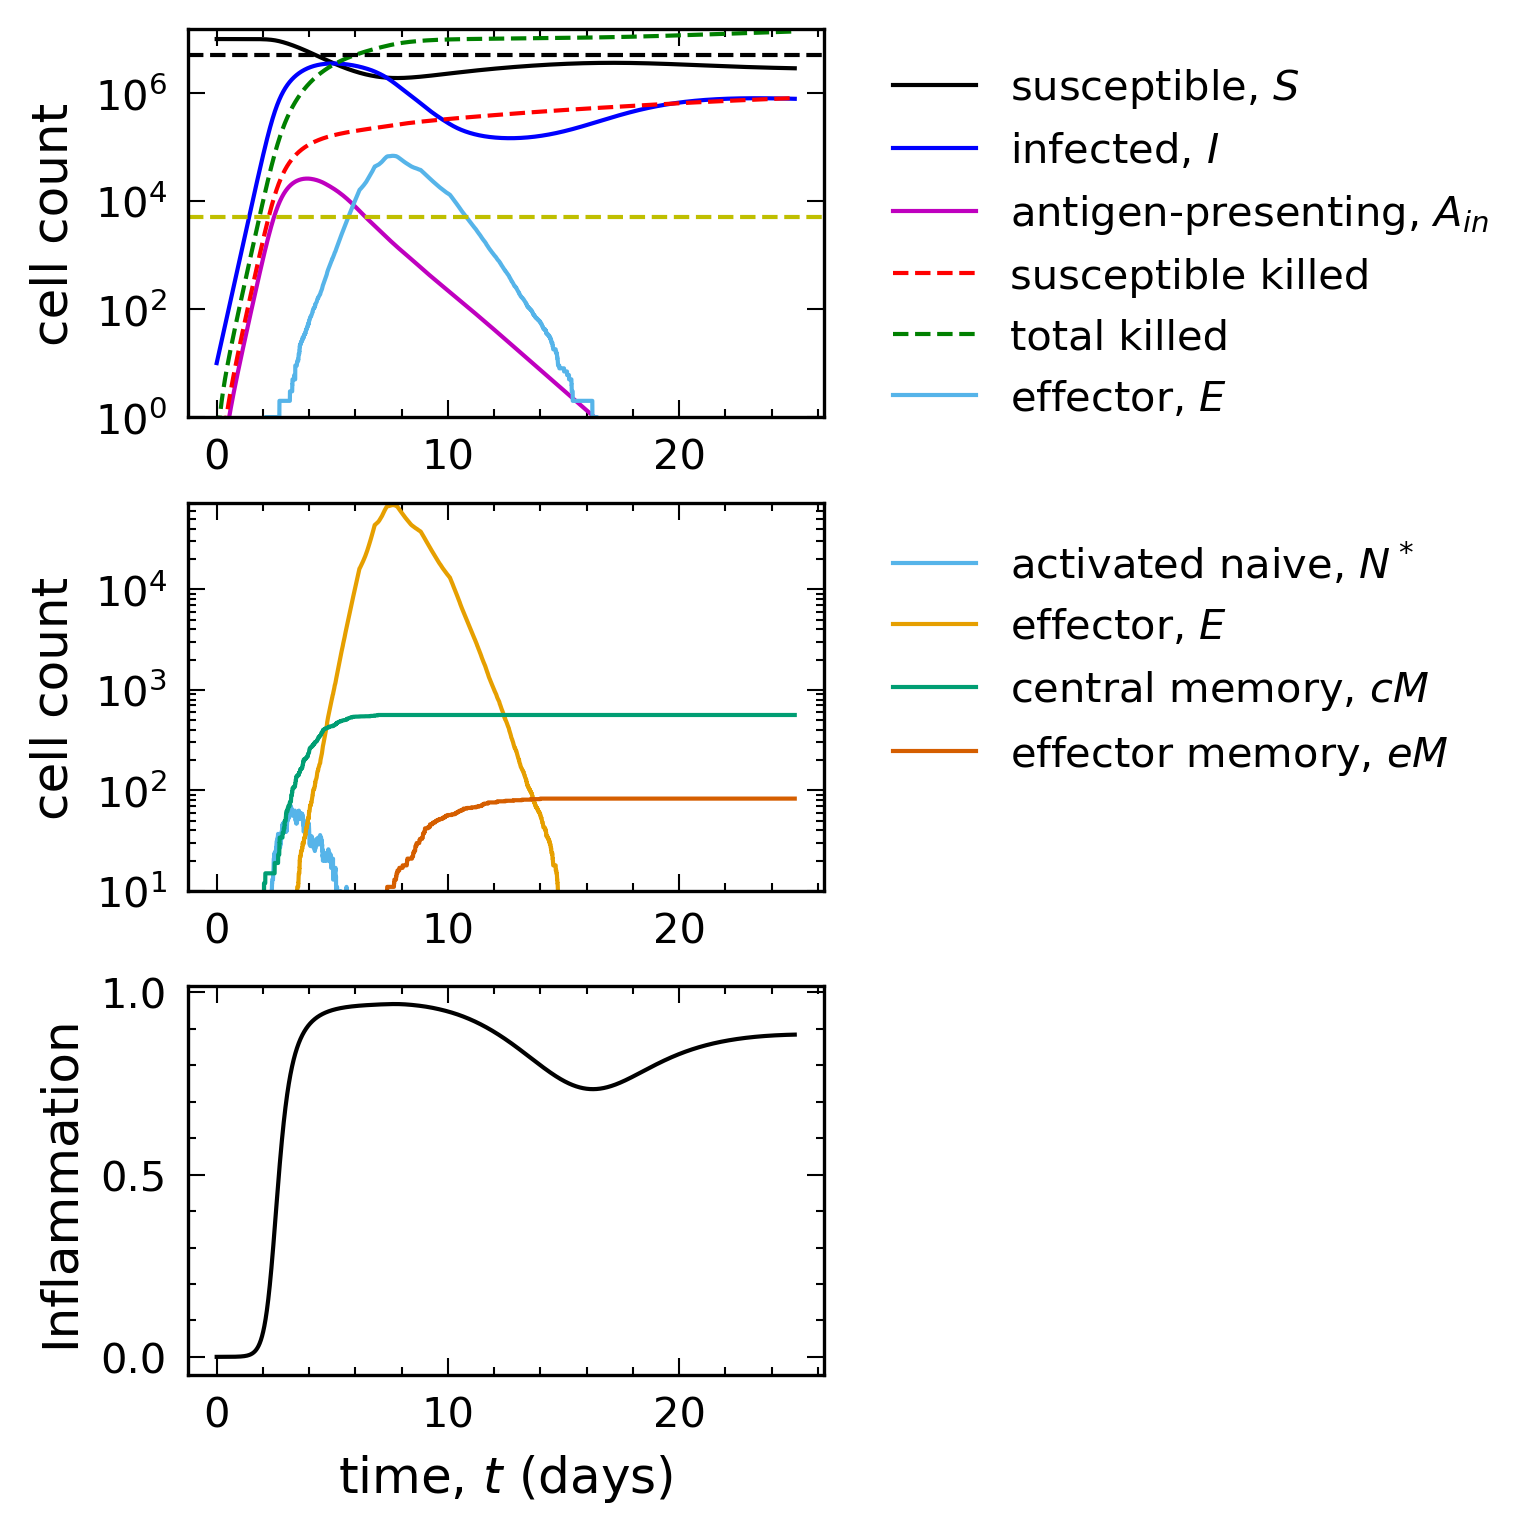

In [47]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(5,5))

ax1.plot(ts, S, 'k', label = r'susceptible, $S$')
ax1.plot(ts, I, 'b', label = r'infected, $I$')
ax1.plot(ts, A, 'm', label = r'antigen-presenting, $A_{in}$')
ax1.plot(ts, I_d_S, 'r', linestyle = '--', label = r'susceptible killed')
ax1.plot(ts, I_d_I+I_d_S, 'g', linestyle = '--', label = r'total killed')
ax1.plot(ts, E, label = r'effector, $E$')
ax1.axhline(y = 0.5*S_0, color = 'k', linestyle = '--')
ax1.axhline(y = 0.01*d_S*S_0, color = 'y', linestyle = '--')
ax1.set(ylabel='cell count')
ax1.set_ylim(1,)
ax1.semilogy()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, Na, label = r'activated naive, $N^*$')
ax2.plot(ts, E, label = r'effector, $E$')
ax2.plot(ts, cM, label = r'central memory, $cM$')
ax2.plot(ts, eM, label = r'effector memory, $eM$')
ax2.set(ylabel='cell count')
ax2.set_ylim(10,)
ax2.semilogy()
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(ts, H**l_H/((K_IH)**l_H + H**l_H),'k-', label = r'inflammation, $H$')
ax3.set(xlabel=r'time, $t$ (days)', ylabel='Inflammation')
#ax3.semilogy()
#ax3.set_ylim(1,)
#ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

fig.savefig("_figs/"+infection_type+'-'+'virus-effector dynamics-'+reg_string+'.png', dpi=300, bbox_inches="tight")

In [48]:
print(f'Memory fraction = {(np.max(cM)+np.max(eM))/np.max(E)}')
print(f'Number of central memory cells = {np.max(cM)}')
print(f'Number of effector memory cells = {np.max(eM)}')
print(f'1st response harm = {sim_summary[-20]/(d_S*S_0/sim_duration)}')
print(f'Minimum susceptible = {np.min(S)/S_0}')

Memory fraction = 0.009382716049382716
Number of central memory cells = 563.0
Number of effector memory cells = 83.0
1st response harm = 690.2967249838256
Minimum susceptible = 0.18974209133425443


Text(0.5, 0.98, 'Peak response response: $N_0=$ 100, $d_I=$0.5')

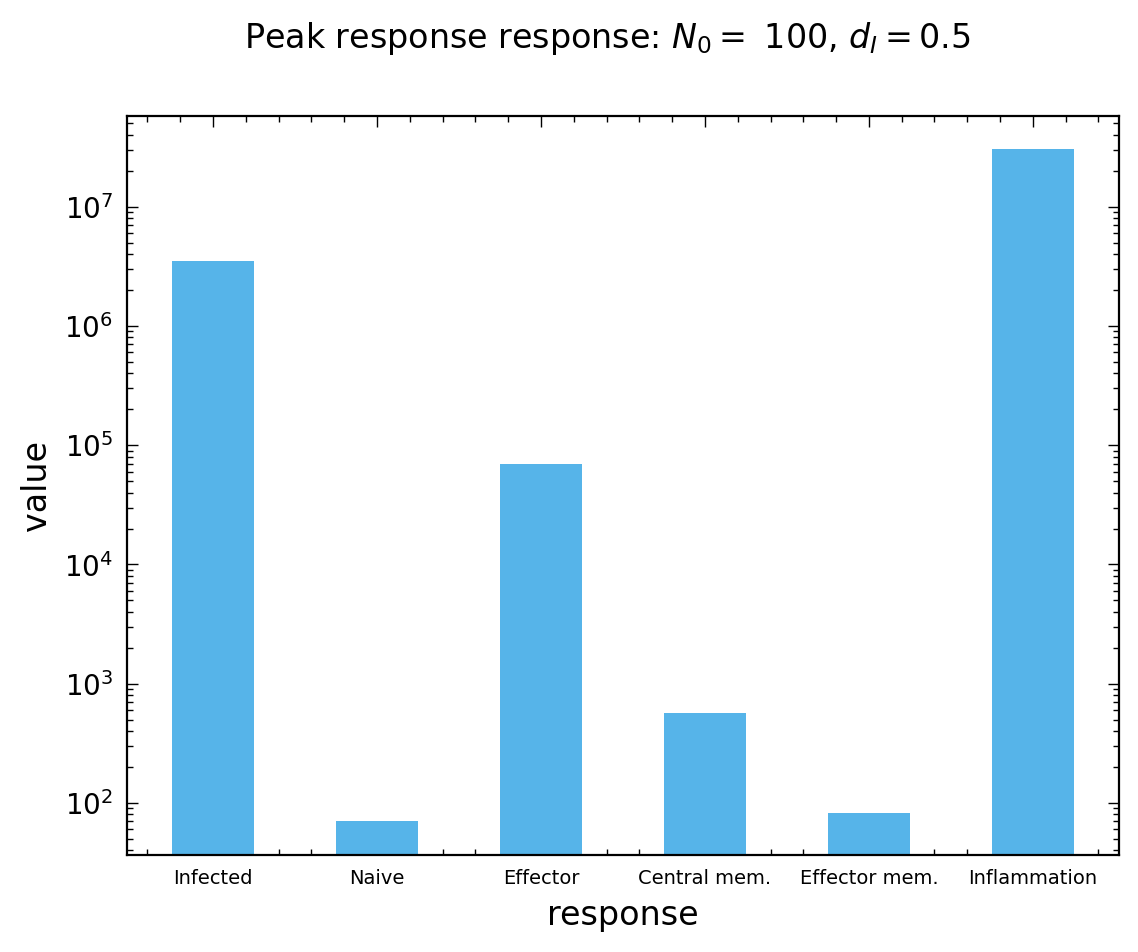

In [49]:
# Compute max values in the data
r = np.arange(6)
width = 0.5
plt.bar(r, np.amax(np.array([I, Na, E, cM, eM, H]).T, axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r, ["Infected","Naive","Effector","Central mem.","Effector mem.", "Inflammation"], fontsize = 7)

plt.semilogy()
plt.suptitle(r'Peak response response: $N_0=$ '+str(N_0) +r', $d_I=$'+str(d_I))
#plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'peak-response'+'.png', dpi=150)

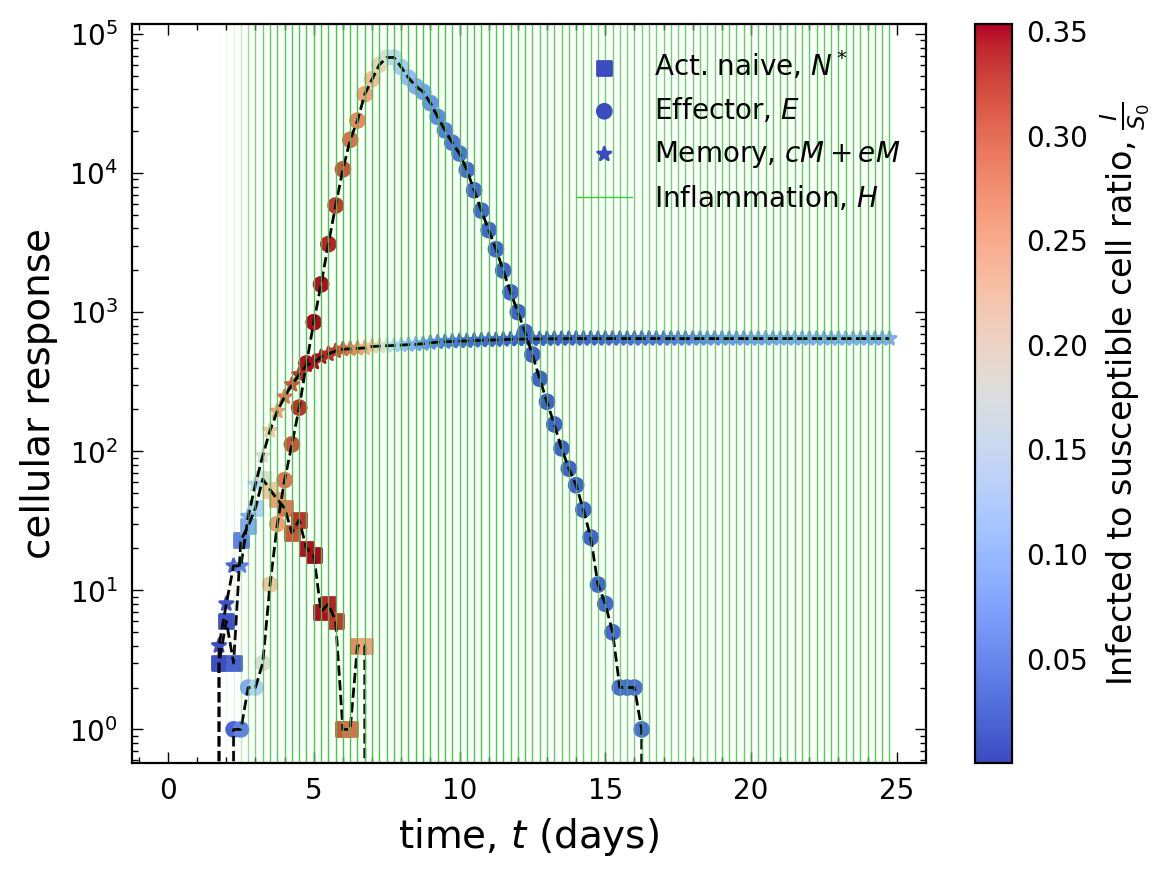

In [50]:
# Plot simulated infection dynamics: pretty plots
pnts = 100
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
sus = S[keep]
naive = Na[keep]
eff = E[keep]
mem = (cM+eM)[keep]
p_load = I[keep]
inflam = H[keep]**l_H/(K_EH**l_H + H[keep]**l_H)
time = ts[keep]

plt.scatter(time, naive, marker ='s', c =p_load/S_0, cmap='coolwarm', 
            label = r'Act. naive, $N^*$') #, norm=mpl.colors.LogNorm())
plt.plot(time, naive, 'k--')
plt.scatter(time, eff, marker ='o', c =p_load/S_0, cmap='coolwarm', 
            label = r'Effector, $E$')
plt.plot(time, eff, 'k--')
plt.scatter(time, mem, marker ='*', c =p_load/S_0, cmap='coolwarm',
            label = r'Memory, $cM+eM$')
plt.plot(time, mem, 'k--')

#plt.axvline(x = time[np.argmin(naive[5:]) + 5], color = 'k', linestyle = '--')

#plt.text('$\tau_I=$ '+str(tau_I) +r', $d_I=$'+str(d_I), fontsize=8)
plt.colorbar(label =r"Infected to susceptible cell ratio, $\frac{I}{S_0}$")
plt.ylabel('cellular response', fontsize = 14)
plt.xlabel(r"time, $t$ (days)", fontsize = 14)
plt.semilogy()

for i in np.arange(0, len(inflam), 1):
    if i == np.argmax(inflam):
        plt.axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i], label =r"Inflammation, $H$")
    else:
        plt.axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i])

plt.legend()

plt.savefig('_figs/'+infection_type+'-timeline-of-infection-dynamics-'+reg_string+'.png', dpi=300, bbox_inches="tight")

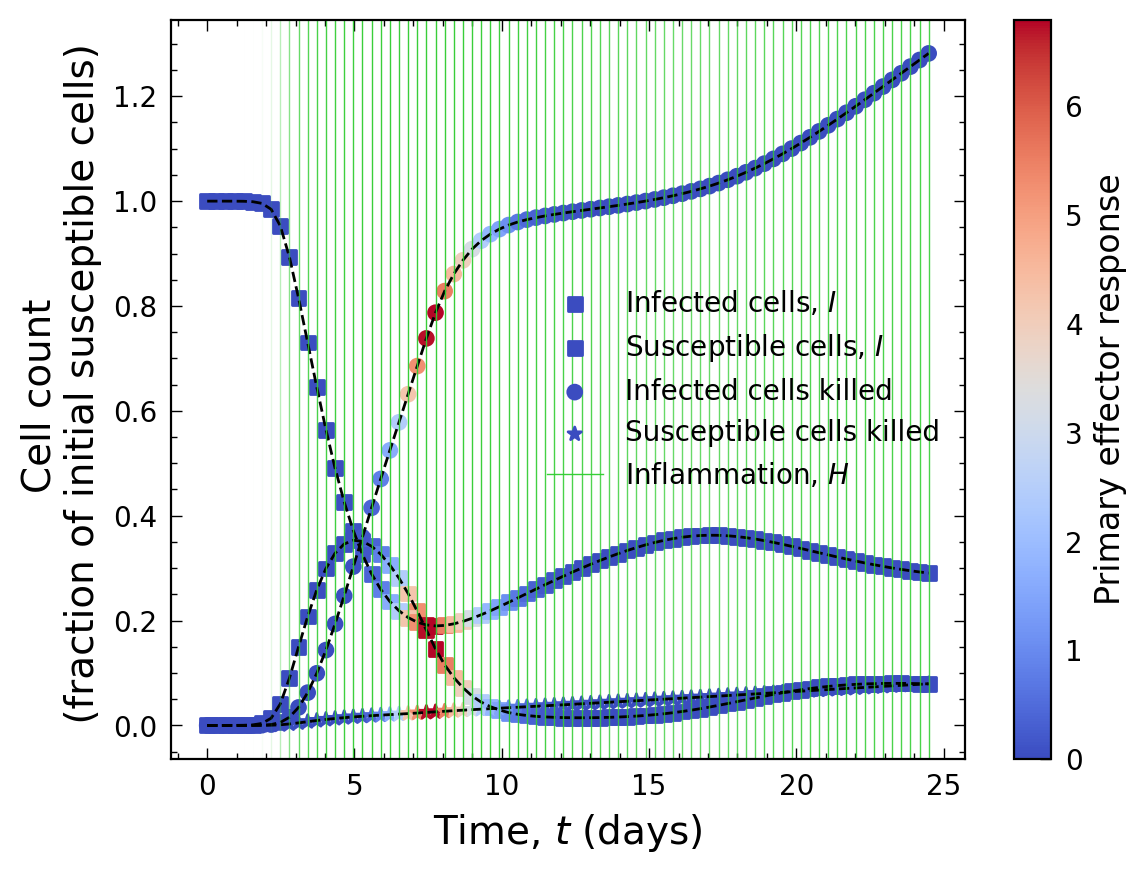

In [51]:
# Plot simulated infection dynamics: pretty plots of harm
pnts = 80
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]

eff = E[keep]
p_load = I[keep]/S_0
sus = S[keep]/S_0
inf_harm = I_d_I[keep]/S_0
inflam_harm = I_d_S[keep]/S_0
inflam = H[keep]**l_H/(K_EH**l_H + H[keep]**l_H)
time = ts[keep]

plt.scatter(time, p_load, marker ='s', c =eff/K_IE, cmap='coolwarm', 
            label = r'Infected cells, $I$') #, norm=mpl.colors.LogNorm())
plt.plot(time, p_load, 'k--')

plt.scatter(time, sus, marker ='s', c =eff/K_IE, cmap='coolwarm', 
            label = r'Susceptible cells, $I$') #, norm=mpl.colors.LogNorm())
plt.plot(time, sus, 'k--')

plt.scatter(time, inf_harm, marker ='o', c =eff/K_IE, cmap='coolwarm', 
            label = 'Infected cells killed')
plt.plot(time, inf_harm, 'k--')

plt.scatter(time, inflam_harm, marker ='*', c =eff/K_IE, cmap='coolwarm',
            label = 'Susceptible cells killed')
plt.plot(time, inflam_harm, 'k--')

plt.colorbar(label = "Primary effector response")
plt.ylabel('Cell count \n (fraction of initial susceptible cells)', fontsize = 14)
plt.xlabel(r"Time, $t$ (days)", fontsize = 14)

for i in np.arange(0, len(inflam), 1):
    if i == np.argmax(inflam):
        plt.axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i], label =r"Inflammation, $H$")
    else:
        plt.axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i])
plt.legend()
plt.savefig('_figs/'+infection_type+'-infection-harm-'+reg_string+'.png', dpi=300, bbox_inches="tight")

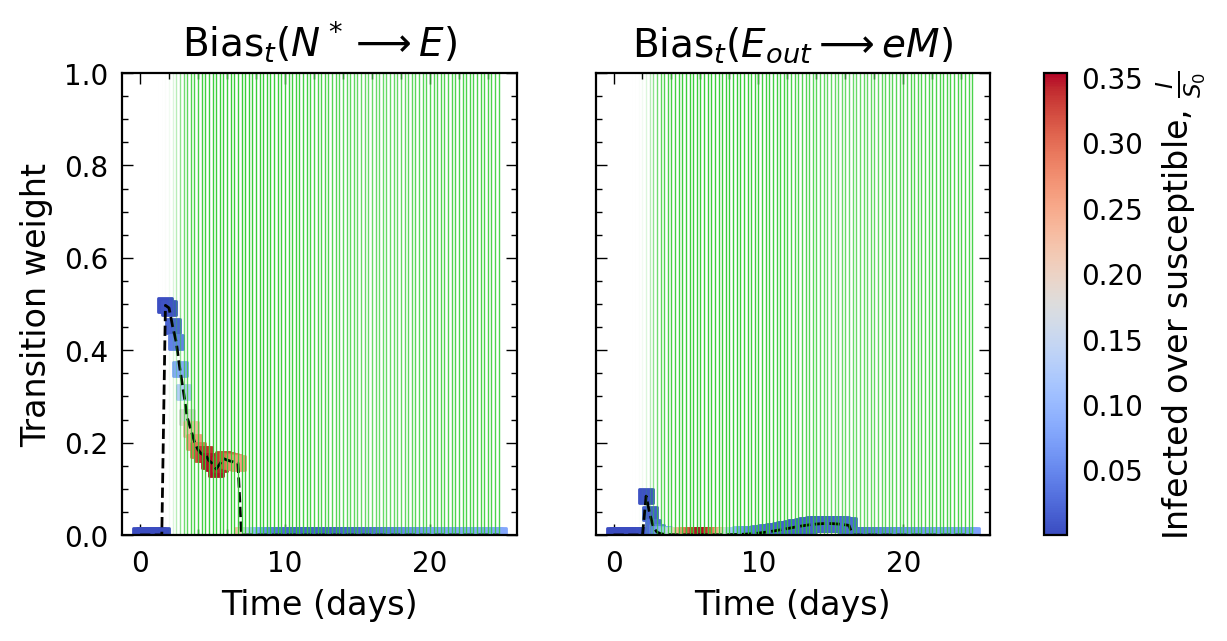

In [52]:
# Plot simulated infection dynamics: pretty plots
pnts = 100
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
bias_diff = p_diff[keep]
p_load = I[keep]
sus = S[keep]
inflam =  H[keep]**l_H/(K_EH**l_H + H[keep]**l_H)
time = ts[keep]

fig, axs = plt.subplots(1,2, figsize=(7,3))

if infection_type == "prim":
    im1 = axs[0].scatter(time, bias_diff[:,0], marker = 's', c =p_load/S_0, cmap='coolwarm', 
                label = r'Bias$_t(N^* \longrightarrow E)$')
    axs[0].plot(time, bias_diff[:,0],'k--')
    axs[0].title.set_text(r'Bias$_t(N^* \longrightarrow E)$')
    axs[0].set_ylim(0,1)
elif infection_type == "sec":
    im1 = axs[0].scatter(time, bias_diff[:,3], marker = 'o', c =p_load/sus, cmap='coolwarm', 
                label = r'$cM$')
    axs[0].scatter(time, bias_diff[:,4], marker = '^', c =p_load/sus, cmap='coolwarm', 
                label = r'$eM$')
    axs[0].plot(time, bias_diff[:,3],'k--')
    axs[0].plot(time, bias_diff[:,4],'k--')
    axs[0].title.set_text(r'Bias$_t(pM \longrightarrow E)$')
    axs[0].legend()
    axs[0].set_ylim(0,1)

# if infection_type == "sec":
#     im2 = axs[2].scatter(time, bias_diff[:,3], marker = 'o', c =p_load/sus, cmap='coolwarm', 
#                 label = r'$\mathbb{P}_t(pM \longrightarrow E)$')
#     axs[2].plot(time, bias_diff[:,3],'k--')
#     axs[2].title.set_text(r'$\mathbb{P}_t(pM \longrightarrow E)$')
#     axs[2].set_ylim(0,1)
# else:
#     im2 = axs[2].scatter(time, bias_diff[:,1], marker = '*', c =p_load/sus, cmap='coolwarm', 
#                     label = r'$\mathbb{P}_t(E_{in} \longrightarrow eM)$')
#     axs[2].plot(time, bias_diff[:,1],'k--')
#     axs[2].title.set_text(r'$\mathbb{P}_t(E_{in} \longrightarrow eM)$')
#     axs[2].set_ylim(0,1)
    
    
im3 = axs[1].scatter(time, bias_diff[:,2], marker = 's', c =p_load/sus, cmap='coolwarm', 
            label = r'Bias$_t(E_{out} \longrightarrow eM)$')
axs[1].plot(time, bias_diff[:,2],'k--')
axs[1].title.set_text(r'Bias$_t(E_{out} \longrightarrow eM)$')
axs[1].set_ylim(0,1)

for i in np.arange(0, len(inflam), 1):
    if i == np.argmax(inflam):
        axs[0].axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i], label =r"Inflammation, $H$")
        axs[1].axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i], label =r"Inflammation, $H$")
    else:
        axs[0].axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i])
        axs[1].axvline(x=time[i], linestyle='-', linewidth=0.5, color='limegreen', alpha=inflam[i], label =r"Inflammation, $H$")

for i, ax in enumerate(axs.flat):
    ax.set(ylabel='Transition weight', 
           xlabel="Time (days)")

for ax in axs.flat:
    ax.label_outer()

cb = fig.colorbar(im1, ax=axs, orientation='vertical')
cb.set_label(r"Infected over susceptible, $\frac{I}{S_0}$")

#cb.set_clim(-0.4,0.4)
    
# plt.colorbar(label =r"pathogen load, $I(t)$")
# plt.ylabel('transition weight', fontsize = 16)
# plt.xlabel("time (days)", fontsize = 16)
# plt.legend() #bbox_to_anchor=(1.05, 1.0), loc='upper left')

plt.savefig('_figs/'+infection_type+'-diff-bias-over-time-'+reg_string+'.png', dpi=300, bbox_inches="tight")

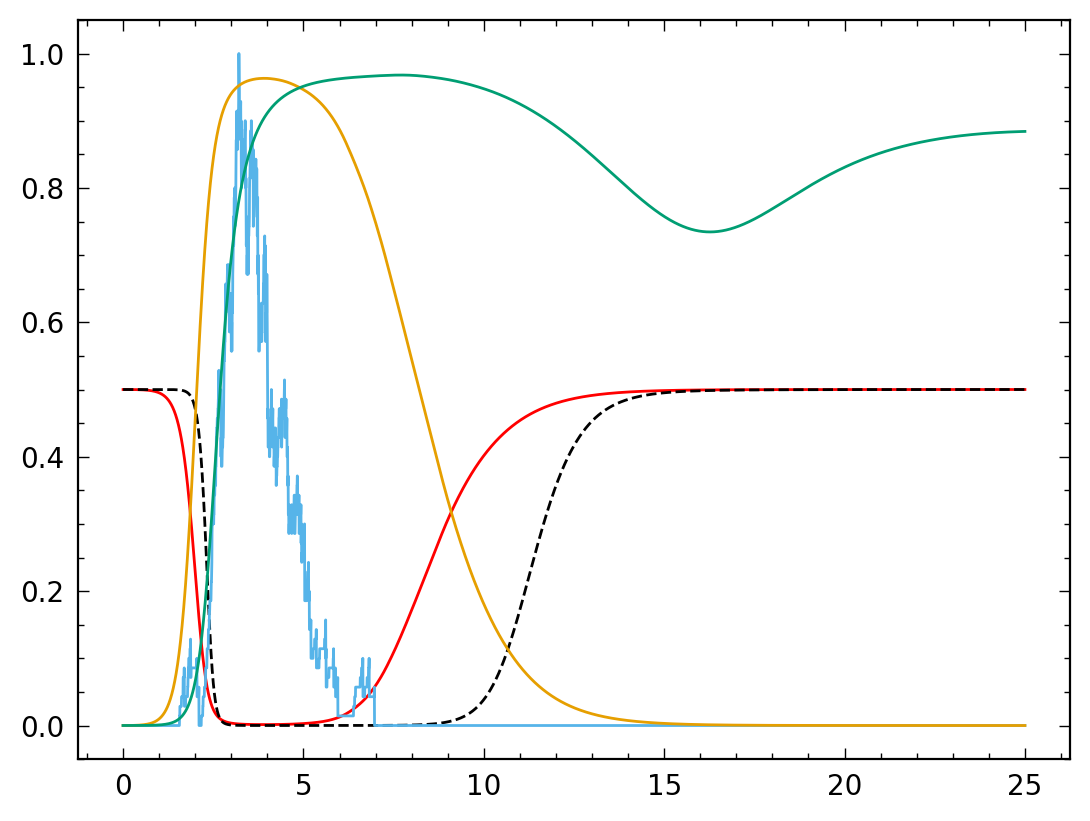

In [53]:
bias_1 = p_XtoY(A, H, 
       -2.0, 0.0, 0.0, F_0 = 0.0, 
       K_I = K_IE/delta_Ain, K_H = K_EH)
bias_2 = p_XtoY(A, H, 
       0.0, 0.0, -2.0, F_0 = 0.0, 
       K_I = K_IE/delta_Ain, K_H = K_EH)

plt.plot(ts, bias_1, 'r')
plt.plot(ts, bias_2, 'k--')
plt.plot(ts, Na/np.amax(Na))
plt.plot(ts, A/(K_IE/delta_Ain + A))
plt.plot(ts, H**l_H/(K_EH**l_H + H**l_H))

In [ ]:
# runs = 2
# vir_samp = np.tile(vir_prop, (int(np.ceil(runs/vir_prop.shape[0])),1))

# run(reg_opt = [172.0], outdir="/mmfs1/home/oukogu/infoimmune", virus_sample = vir_samp)

Entered reg_opt = 172.0
Running with regs = [-1.5, 1.5, 0.0, -3.0, 0.0, 0.0, 3.0, 0.0, 0.0]
Will save to /mmfs1/home/oukogu/infoimmune/-1.5-1.5-0.0--3.0-0.0-0.0-3.0-0.0-0.0-400-sec--ncv.pkl.
Running simulation


/opt/minimamba/envs/maximmune/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [36]:
[0.5, -0.5, 0.0, 0.0, 0.0, 1.0, 0.5, -0.5, 0.0]
d_file = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw/1.0--1.0-0.0-0.0-0.0-2.0-1.0--1.0-0.0-200-sec--ncv.pkl'
with open(d_file, 'rb') as f:   
    out = pickle.load(f)

In [44]:
dyn_data = out["cell_time_series"][4]
ts = out["time"][4]
print(out["sumary_stats"][4])
pS, sS, pI, sI, sAin, sN, pE, sE, pcM, scM, peM, seM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_data[:,0], dyn_data[:,-10], dyn_data[:,1], dyn_data[:,-9], dyn_data[:,-8], dyn_data[:,3], dyn_data[:, 4], dyn_data[:,-6], dyn_data[:,5], dyn_data[:, -5], dyn_data[:,6], dyn_data[:,-4], dyn_data[:,7], dyn_data[:,-3], dyn_data[:,8], dyn_data[:,-2], dyn_data[:,9], dyn_data[:,-1]

[ 1.00000000e+07  1.00000000e+01  2.50000000e-07  5.00000000e-02
  2.50000000e-01  1.20000000e+01  1.80000000e-03  1.00000000e+04
  5.00000000e+06  1.00000000e+04  2.00000000e+00  4.00000000e+00
  5.00000000e-01  5.00000000e+05  1.00000000e+02  4.00000000e+00
  1.50000000e+03  2.37650462e+00  3.98107171e+02  5.00000000e-01
  7.50000000e-01  2.50000000e-01  3.33333333e-01  5.00000000e-01
  4.50000000e+00  1.00000000e+00  3.00000000e+00  1.00000000e+00
  5.00000000e-01  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  3.00000000e+00  1.00000000e+00
  6.00000000e+00  1.00000000e+00  3.00000000e+00  1.00000000e+00
 -1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  2.00000000e+00  1.00000000e+00 -1.00000000e+00  0.00000000e+00
  3.70565273e+05  3.87321076e+02  6.86500000e+00  3.52500000e+00
  2.96658381e+05  9.53280773e+02  9.44929903e+04  7.51045055e+03
  3.84661000e+05  1.13340000e+04  7.95500000e+00  4.60500000e+00
  2.92000000e+02  1.86000

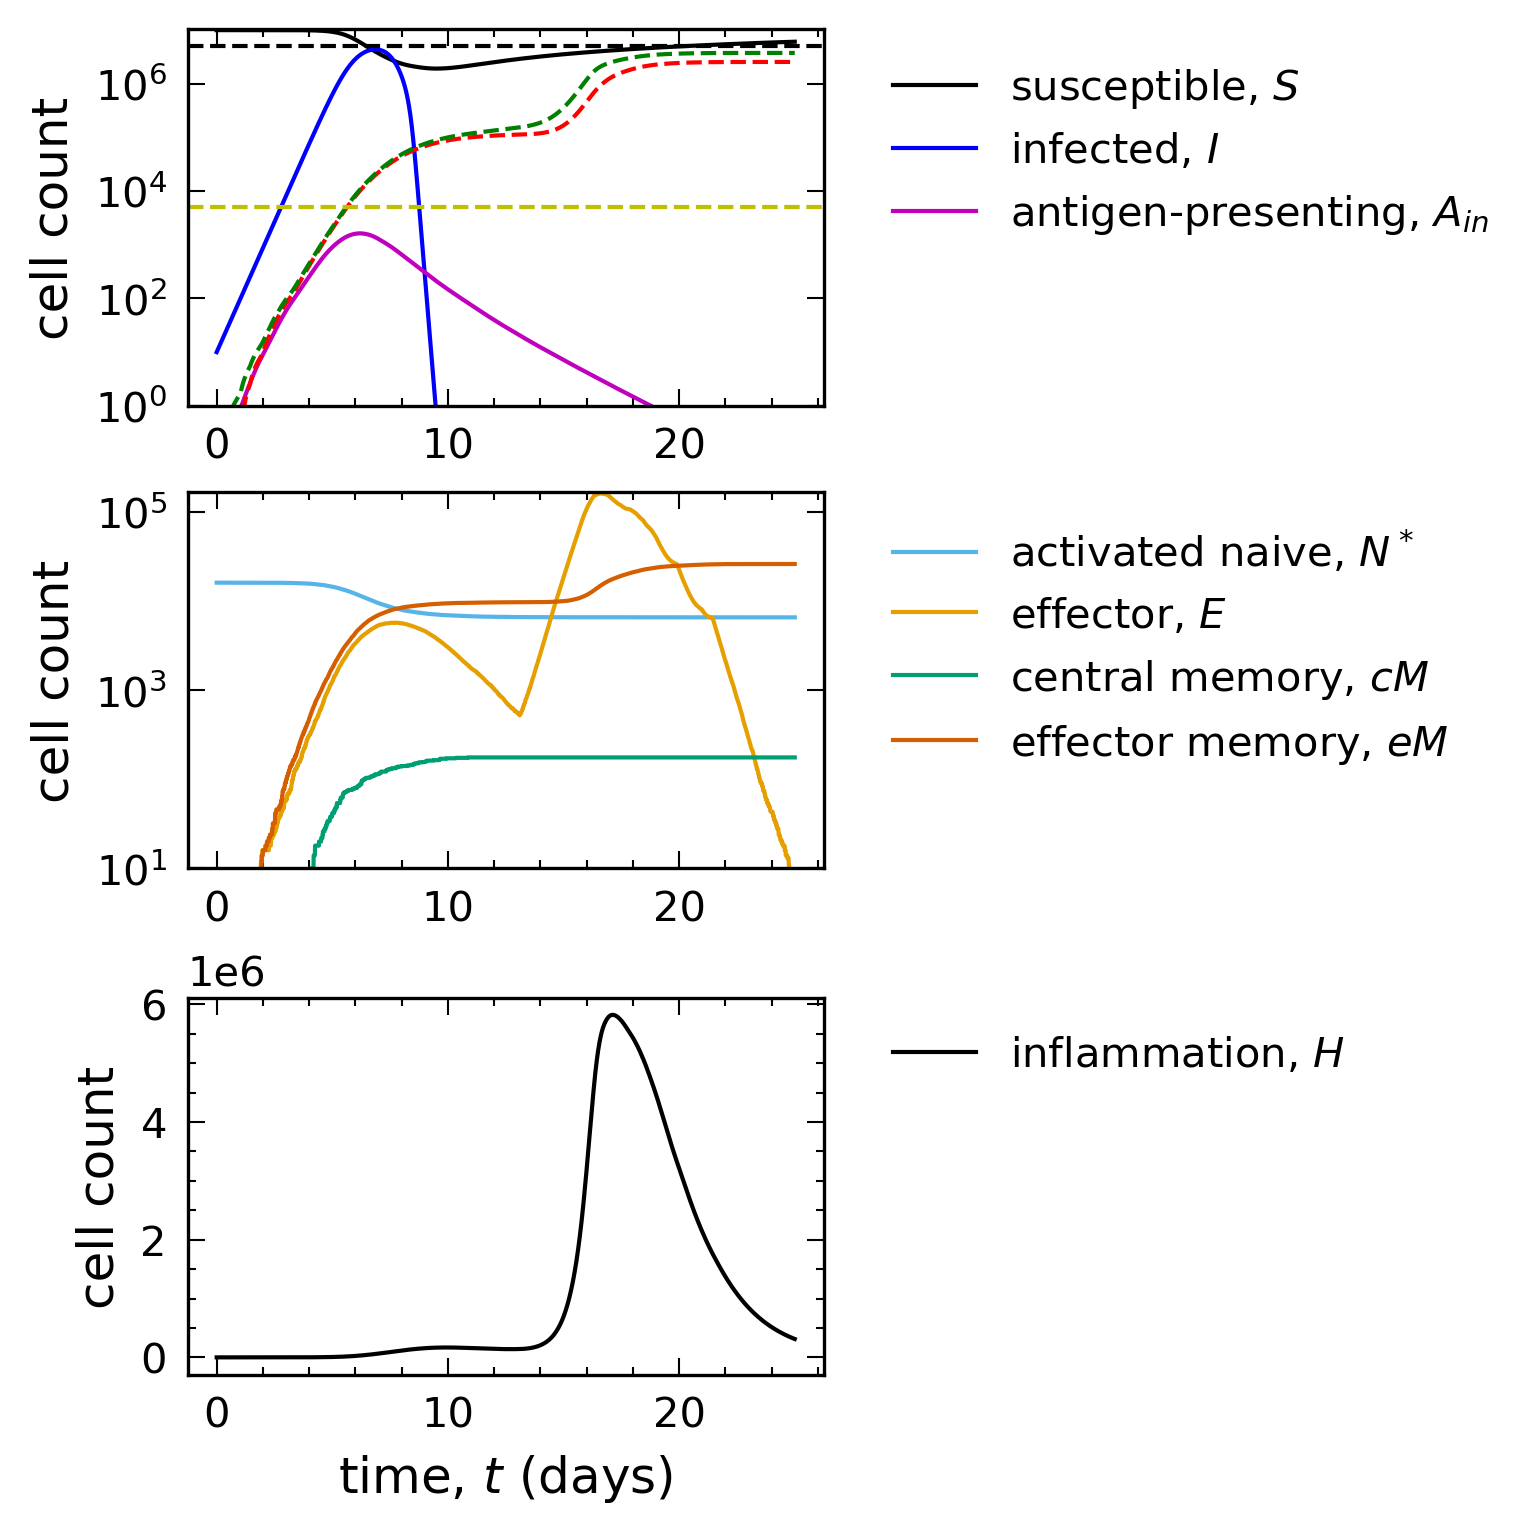

In [45]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(5,5))

ax1.plot(ts, pS, 'k', label = r'susceptible, $S$')
ax1.plot(ts, pI, 'b', label = r'infected, $I$')
ax1.plot(ts, A, 'm', label = r'antigen-presenting, $A_{in}$')
ax1.plot(ts, I_d_S, 'r', linestyle = '--')
ax1.plot(ts, I_d_I+I_d_S, 'g', linestyle = '--')
ax1.axhline(y = 0.5*S_0, color = 'k', linestyle = '--')
ax1.axhline(y = 0.01*d_S*S_0, color = 'y', linestyle = '--')
ax1.set(ylabel='cell count')
ax1.set_ylim(1,)
ax1.semilogy()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, Na, label = r'activated naive, $N^*$')
ax2.plot(ts, E, label = r'effector, $E$')
ax2.plot(ts, cM, label = r'central memory, $cM$')
ax2.plot(ts, eM, label = r'effector memory, $eM$')
ax2.set(ylabel='cell count')
ax2.set_ylim(10,)
ax2.semilogy()
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(ts, H,'k-', label = r'inflammation, $H$')
ax3.set(xlabel=r'time, $t$ (days)', ylabel='cell count')
#ax3.semilogy()
#ax3.set_ylim(1,)
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

In [ ]:
n = int(num_categories/2) + 1
fig, axs = plt.subplots(n_virs+1,n, figsize=(2*n + 4, 2*(n_virs+1)), sharex=True, sharey='row')
time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]

for l, (d_I, K_IE) in tqdm(enumerate(chosen_virs)):

    for i, category in enumerate(perf_categories[:5]):
        k = np.where((vir_prop[:,0] == d_I)*(vir_prop[:,1] == K_IE))[0].item()
        diff_index = i + num_categories*k
        
        p_data = np.array(p_diff_data_for_dmd[diff_index])
        dyn_data = np.array(dyn_data_for_dmd[diff_index])
        if np.isnan(dyn_data).all() == False:
            pS, sS, pI, sI, Ain, N, pE, sE, pcM, scM, peM, seM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_data[:,:,0], dyn_data[:,:,-10], dyn_data[:,:,1], dyn_data[:,:,-9], dyn_data[:,:,-8], dyn_data[:,:,-7], dyn_data[:,:, 4], dyn_data[:,:,-6], dyn_data[:,:,5], dyn_data[:,:, -5], dyn_data[:,:,6], dyn_data[:,:,-4], dyn_data[:,:,7], dyn_data[:,:,-4], dyn_data[:,:,8], dyn_data[:,:,-2], dyn_data[:,:,9], dyn_data[:,:,-1]

            im = axs[l,i].scatter(time, np.mean(N, axis = 0), c =np.mean(pI, axis = 0)/S_0, marker ='s', cmap='coolwarm', 
            label = r'Act. naive, $N^*$') #, norm=mpl.colors.LogNorm())
            axs[l,i].plot(time, np.mean(N, axis = 0), 'k--')
            
            axs[l,i].scatter(time, np.mean(pE, axis = 0), c =np.mean(pI, axis = 0)/S_0, marker ='o', cmap='coolwarm', 
                        label = r'Effector, $E$')
            axs[l,i].plot(time, np.mean(pE, axis = 0), 'k--')
            
            axs[l,i].scatter(time, np.mean(pcM + peM, axis = 0), c =np.mean(pI, axis = 0)/S_0, marker ='*', cmap='coolwarm',
                        label = r'Memory, $cM+eM$')
            axs[l,i].plot(time, np.mean(pcM + peM, axis = 0), 'k--')

            axs[l,i].semilogy()
            
            [axs[l,i].axvline(x=time[j], linestyle='-', linewidth=0.3, color='limegreen', alpha=np.mean(pH[:,j])/(K_EH + np.mean(pH[:,j])), zorder = 0) for j in np.arange(0, pnts-1)]
        
                
        if i == 0:
            axs[l,0].set_ylabel(r"$d_I =$ "+str(int(d_I/d_S))+r"$\times d_S$"+",\n"+r"$K_{I,E} =$ "+str(np.round(K_IE/K_SE,3))+r"$\times K_{S,E}$", fontsize = 10)
        
        if l == 0:
            if i == 0:
                axs[0,i].set_title('Biologically \n motivated', fontsize = 8)
            else:
                axs[0,i].set_title(r'Top '+str(int((1-cutoff)*100))+'%'+' in \n'+perf_labels[i-1], fontsize = 8)

axs[0,0].axvline(x=time[np.argmax(np.mean(pH, axis = 0))], linestyle='-', linewidth=0.3, color='limegreen', alpha=np.max(np.mean(pH, axis = 0))/(K_EH + np.max(np.mean(pH, axis = 0))), label =r"Inflammation, $H$")
axs[0,0].legend(loc='center right', bbox_to_anchor=(7.5, 0.7), fontsize = 14)

cb = fig.colorbar(im, ax=axs, orientation='vertical', shrink = 0.6, pad = 0.05)
cb.set_label("Infection load", fontsize = 12)

for i, ax in enumerate(axs.flat):
    ax.set_xlabel(r"time, $t$ (days)", fontsize = 10)

for ax in axs.flat:
    ax.label_outer()

plt.savefig('_figs/mean_cell_dynamics_by_category', dpi=300, bbox_inches='tight')

In [34]:
x_all = np.array(list(itertools.product([-1,-0.5, 0, 0.5, 1], repeat =3)))
x_contr = x_all[(np.sum(np.abs(x_all), axis = 1) == 1) + (np.sum(np.abs(x_all), axis = 1) == 0)]

In [35]:
len(x_contr)

19

In [24]:
19**3

6859